<center><h1 style="background: skyblue; color: black;">🐦‍🔥 Basic Image Classification</h1></center>

# **1. Path Solution**

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\RAMAN KUMAR\OneDrive\Desktop\Projects\basic-image-classification


# **2. Importing libraries and CIFAR10 dataset**

In [2]:
import numpy as np, matplotlib.pyplot as plt, tensorflow as tf, keras 
from keras.datasets import cifar10

# **3. Loading and Spliting data into Training and Testinng**

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# **4. Checking Shapes of Training and Testing datasets**

In [4]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


# **5. Display first image**

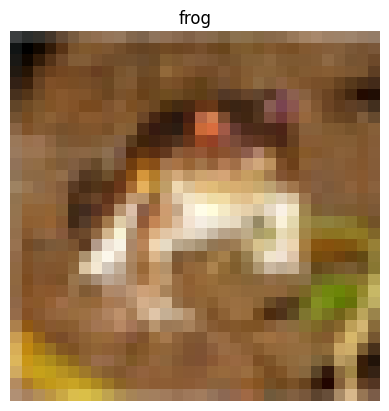

In [5]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

plt.imshow(X_train[0])
plt.title(class_names[int(y_train[0][0])])
plt.axis("off")
plt.show()

# **6. Pixel value range**

In [6]:
print(f"Minimum pixel value: {X_train.min()}")
print(f"Maximum pixel value: {X_train.max()}")

Minimum pixel value: 0
Maximum pixel value: 255


# **7. Visualize Top 16 images**

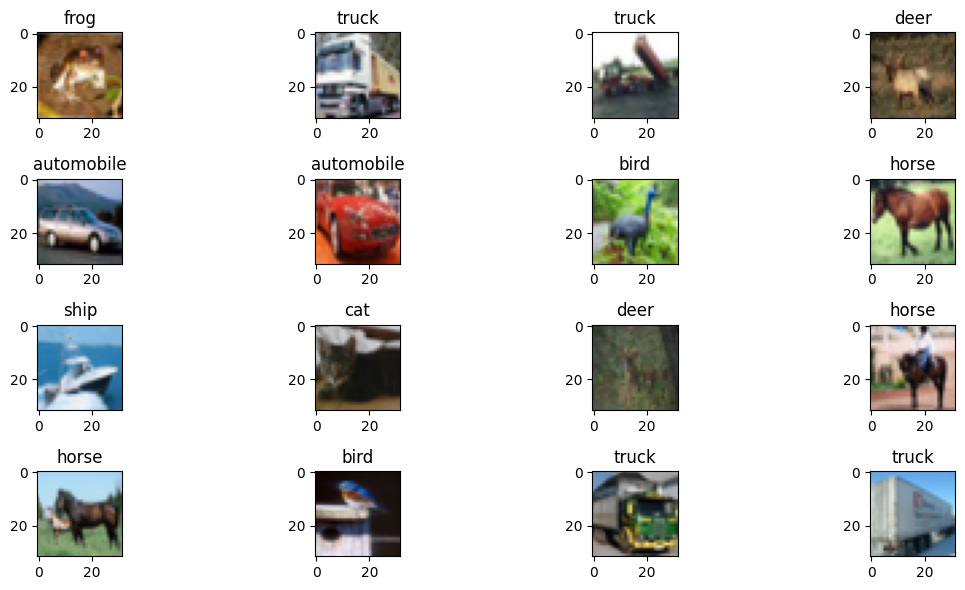

In [7]:
fig, ax = plt.subplots(4, 4, figsize=(12, 6))

count = 0
for i in range(4):
    for j in range(4):
        ax[i, j].imshow(X_train[count])
        ax[i, j].set_title(class_names[int(y_train[count][0])])
        count += 1

plt.tight_layout()
plt.show()

# **8. Class Distribution**

In [8]:
print(np.unique(y_train))
print(len(np.unique(y_train)))

[0 1 2 3 4 5 6 7 8 9]
10


# **9. Normalization for faster convergence, more stable gradients, and better numerical behaviour**

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Shapes:")
print(X_train.shape)
print(X_test.shape)

print("\nData Type & Pixel Values:")
print(X_train.dtype)
print(X_train.min())
print(X_train.max())

Shapes:
(50000, 32, 32, 3)
(10000, 32, 32, 3)

Data Type & Pixel Values:
float32
0.0
1.0


# **10. Building the Convolution Neural Network (CNN) model**

In [10]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32, 3, 1, activation="relu", input_shape=(32, 32, 3)), # After Conv2D -> 30 * 30 * 3
    keras.layers.MaxPool2D((2, 2)), # After MaxPool2D -> 15 * 15 * 3
    keras.layers.Conv2D(64, 3, 1, activation="relu"), # After Conv2D -> 13 * 13 * 64
    keras.layers.MaxPool2D((2, 2)), # After MaxPool2D -> 6 * 6 * 64
    keras.layers.Flatten(), # After Flatten -> 6*6*64 = 2304
    keras.layers.Dropout(0.5), # After model training (Attempt 1), I found - Model was overfitting. So I used Dropout
    keras.layers.Dense(64, activation="relu"), # Hidden Layer
    keras.layers.Dense(10, activation="softmax") # Output Layer
])

c:\Users\RAMAN KUMAR\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **11. Compiling the model**

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# **12. View Model Summary**

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

# **13. Model Training**

In [13]:
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20, # After model training (Attempt 1), I used 20 for more training. Before I used 10
    validation_data=(X_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.4285 - loss: 1.5811 - val_accuracy: 0.5447 - val_loss: 1.2891
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.5488 - loss: 1.2658 - val_accuracy: 0.6009 - val_loss: 1.1320
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.5943 - loss: 1.1554 - val_accuracy: 0.6431 - val_loss: 1.0215
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6201 - loss: 1.0793 - val_accuracy: 0.6521 - val_loss: 0.9885
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6432 - loss: 1.0155 - val_accuracy: 0.6624 - val_loss: 0.9779
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6608 - loss: 0.9688 - val_accuracy: 0.6928 - val_loss: 0.8896
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.6700 - loss: 0.9341 - val_accuracy: 0.6897 - val_loss: 0.8893
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6859 - loss: 0.8977 - 

# **14. Visualization of Accuracy & Loss**

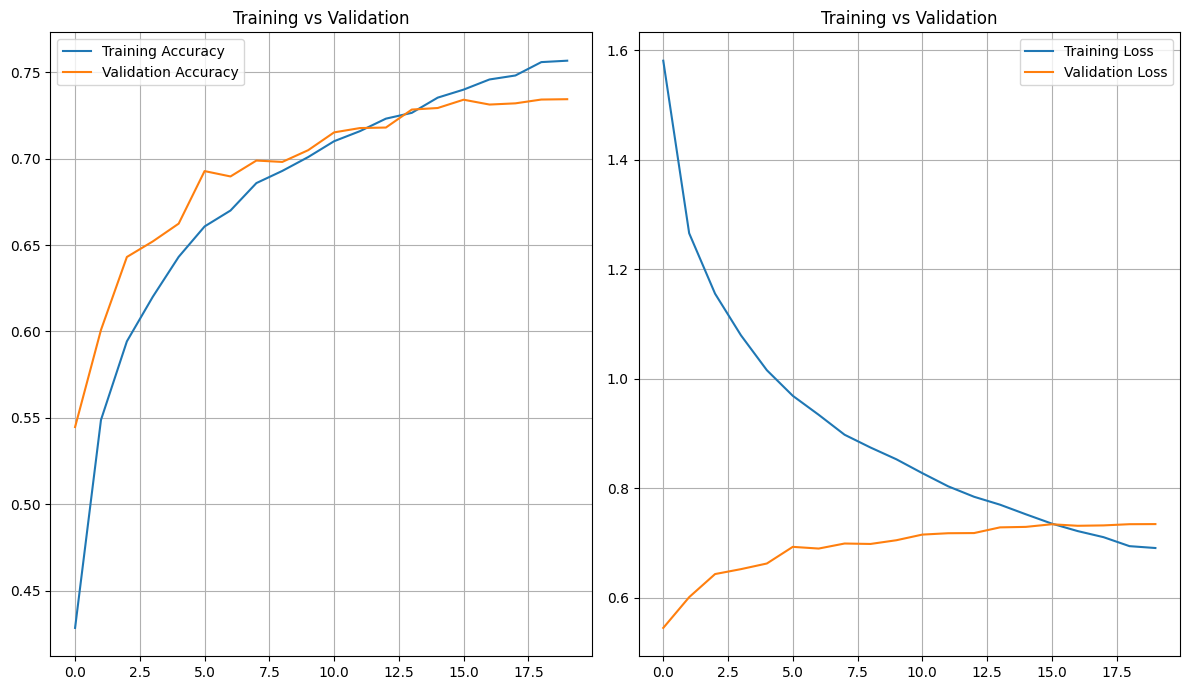

In [14]:
plt.figure(figsize=(12, 7))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Training vs Validation")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_accuracy'], label="Validation Loss")
plt.title("Training vs Validation")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# **15. Final Accuracy and Loss**

In [17]:
print(f"FInal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

FInal Training Accuracy: 0.7567
Final Validation Accuracy: 0.7344
Final Training Loss: 0.6907
Final Validation Loss: 0.7725


# **16. Model Evaluation**

In [21]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

preds_proba = model.predict(X_test)
preds = np.argmax(preds_proba, axis=1)
print(f"\nConfusion Matrix: \n{confusion_matrix(y_test, preds)}")
print(f"\nClassification Report: \n{classification_report(y_test, preds)}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7344 - loss: 0.7725
Test Loss: 0.7725
Test Accuracy: 0.7344
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Confusion Matrix: 
[[769  10  37  30  16   9   3  10  75  41]
 [ 17 772   6  16   3   7  10   3  29 137]
 [ 59   0 586  76  74 104  48  26  11  16]
 [ 17   6  46 568  52 210  38  31  14  18]
 [ 13   1  54  80 671  59  35  71  11   5]
 [  6   0  41 167  37 686  11  37   5  10]
 [  6   2  37 101  29  35 770   7  10   3]
 [  8   1  19  34  45  82   1 801   2   7]
 [ 46  15   7  18   6  11   3   2 860  32]
 [ 18  34  11  13   4   8   6  15  30 861]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.80      0.77      0.79      1000
           1       0.92      0.77      0.84      1000
           2       0.69      0.59      0.64      1000
           3       0.51      0.57      0.54      1000
           4       0.72      0.67      0.69      1000
           5       0.57      0.69      0.62

# **17. Visualize Predictions**

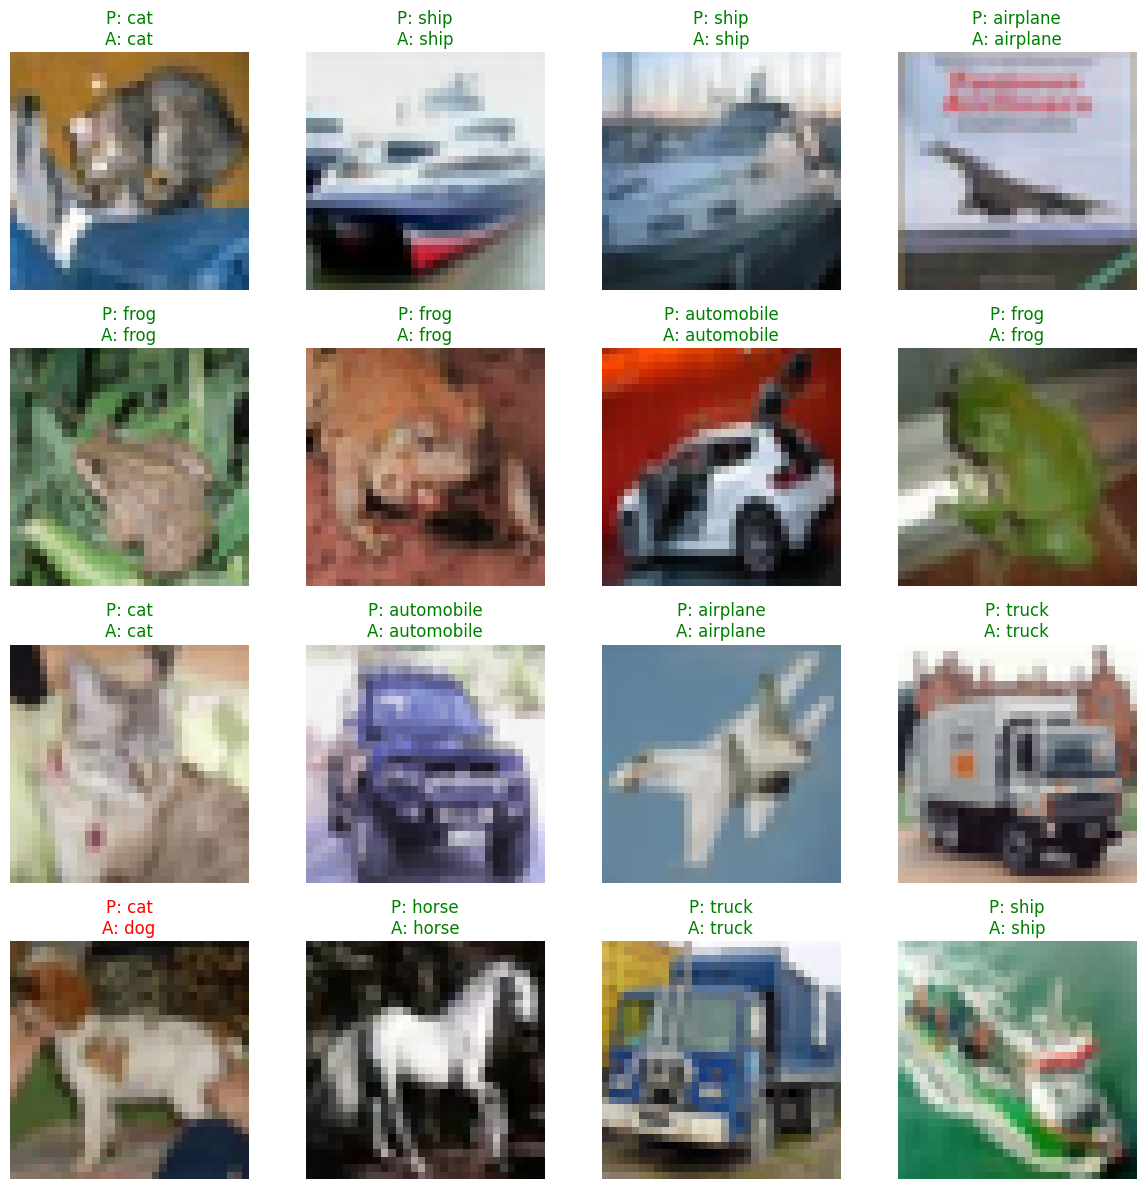

In [25]:
plt.figure(figsize=(12, 12))

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_test[i])

    predicted_label = class_names[preds[i]]
    actual_label = class_names[int(y_test[i, 0])]

    if preds[i] == y_test[i]:
        title_color = "green"
    else:
        title_color = "red"
    
    plt.title(f"P: {predicted_label}\nA: {actual_label}", color=title_color)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **18. Saving the model**

In [27]:
model.save(PROJECT_ROOT / "models/cifar10_cnn.keras")

# **19. Loading the saved model**

In [28]:
from keras.models import load_model

loaded_model = load_model(PROJECT_ROOT / "models/cifar10_cnn.keras")
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 502,688 (1.92 MB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 335,126 (1.28 MB)

# **20. Testing**

In [29]:
sample_pred = loaded_model.predict(X_test[:1])
print(np.argmax(sample_pred, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
[3]
